In [2]:
# Import Required Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [ ]:
# Load the Heart Failure Prediction dataset

df = pd.read_csv("../dataset/heart.csv")

# Display the first five rows of the dataset

df.head()


Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='str')

In [5]:
# Display the number of rows and columns
df.shape

(918, 12)

In [6]:
# Display all column names
df.columns

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='str')

In [7]:
# Display dataset information
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    str    
 2   ChestPainType   918 non-null    str    
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    str    
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    str    
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    str    
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), str(5)
memory usage: 86.2 KB


In [8]:
# Display statistical summary
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [9]:
# Check missing values in each column
df.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

In [10]:
# Count duplicate rows
df.duplicated().sum()

np.int64(0)

In [11]:
# Display data types of all columns
df.dtypes

Age                 int64
Sex                   str
ChestPainType         str
RestingBP           int64
Cholesterol         int64
FastingBS           int64
RestingECG            str
MaxHR               int64
ExerciseAngina        str
Oldpeak           float64
ST_Slope              str
HeartDisease        int64
dtype: object

In [12]:
# Display the number of unique values in each column
df.nunique()


Age                50
Sex                 2
ChestPainType       4
RestingBP          67
Cholesterol       222
FastingBS           2
RestingECG          3
MaxHR             119
ExerciseAngina      2
Oldpeak            53
ST_Slope            3
HeartDisease        2
dtype: int64

In [13]:
# Display unique values of categorical columns
categorical_columns = df.select_dtypes(include="object").columns

for column in categorical_columns:
    print(f"\n{column}:")
    print(df[column].unique())


Sex:
<StringArray>
['M', 'F']
Length: 2, dtype: str

ChestPainType:
<StringArray>
['ATA', 'NAP', 'ASY', 'TA']
Length: 4, dtype: str

RestingECG:
<StringArray>
['Normal', 'ST', 'LVH']
Length: 3, dtype: str

ExerciseAngina:
<StringArray>
['N', 'Y']
Length: 2, dtype: str

ST_Slope:
<StringArray>
['Up', 'Flat', 'Down']
Length: 3, dtype: str


In [14]:
# Distribution of Target Variable

# Count the number of patients with and without heart disease
df["HeartDisease"].value_counts()

HeartDisease
1    508
0    410
Name: count, dtype: int64

In [15]:
# Gender Distribution

df["Sex"].value_counts()

Sex
M    725
F    193
Name: count, dtype: int64

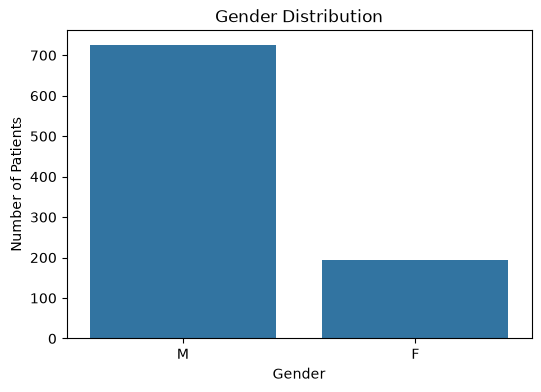

In [16]:
# Visualize Target Values

plt.figure(figsize=(6,4))

sns.countplot(x="Sex", data=df)

plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Number of Patients")

plt.show()

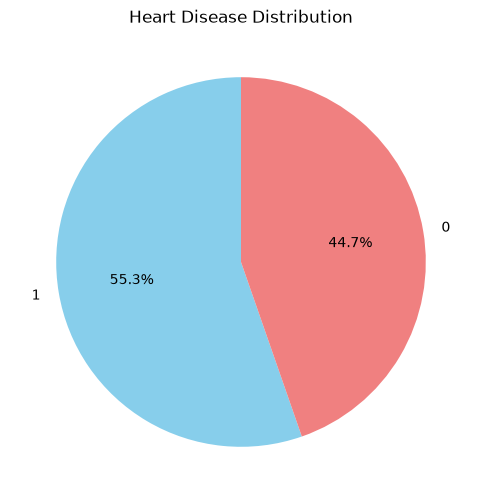

In [17]:
# Heart Disease Distribution (Pie Chart)

plt.figure(figsize=(6,6))

df["HeartDisease"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90,
    colors=["skyblue", "lightcoral"]
)

plt.title("Heart Disease Distribution")
plt.ylabel("")

plt.show()

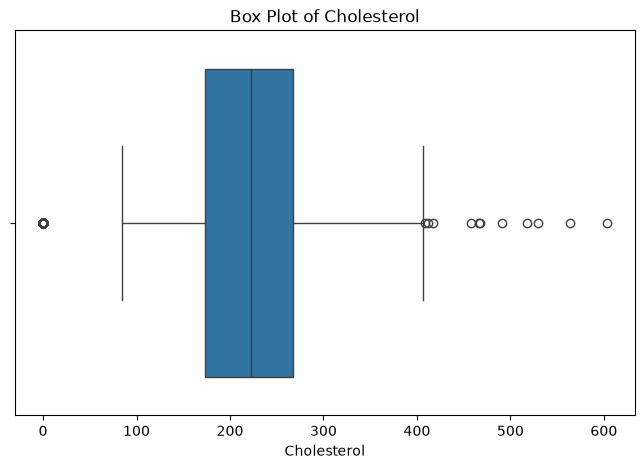

In [18]:
# Cholesterol Distribution

plt.figure(figsize=(8,5))

sns.boxplot(x=df["Cholesterol"])

plt.title("Box Plot of Cholesterol")

plt.show()

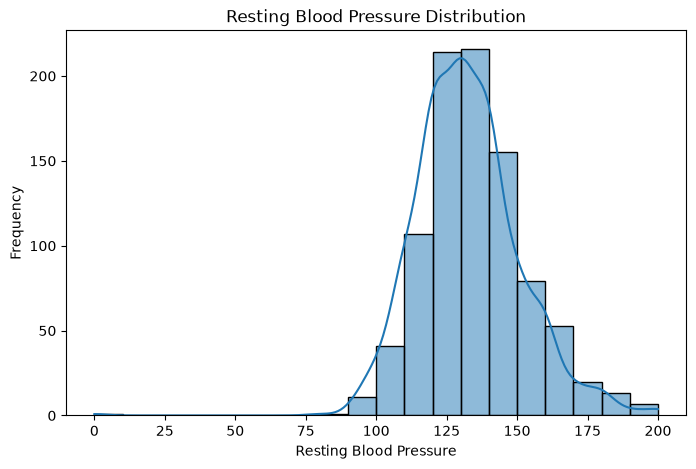

In [19]:
# Resting Blood Pressure Distribution

plt.figure(figsize=(8,5))

sns.histplot(df["RestingBP"], bins=20, kde=True)

plt.title("Resting Blood Pressure Distribution")

plt.xlabel("Resting Blood Pressure")

plt.ylabel("Frequency")

plt.show()

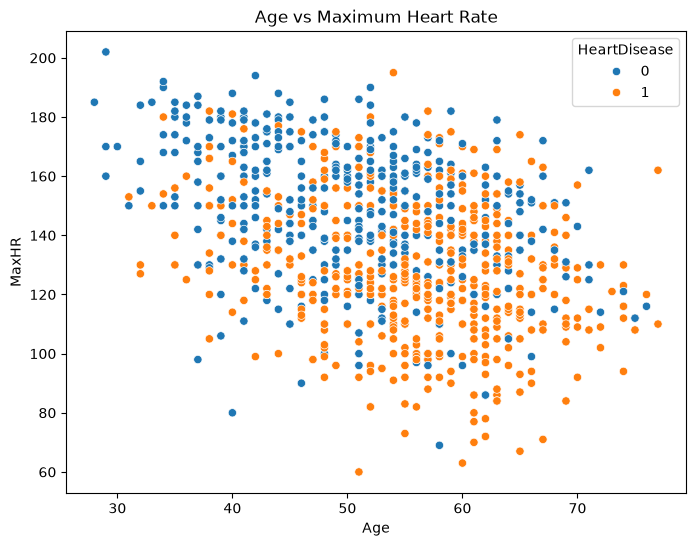

In [20]:
# Age vs Maximum Heart Rate

plt.figure(figsize=(8,6))

sns.scatterplot(
    x="Age",
    y="MaxHR",
    hue="HeartDisease",
    data=df
)

plt.title("Age vs Maximum Heart Rate")

plt.show()

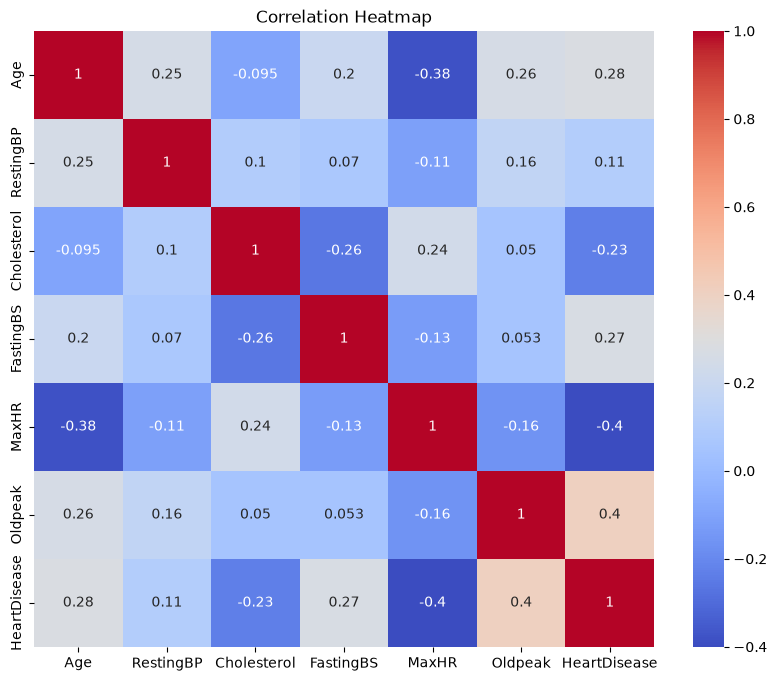

In [21]:
# Correlation Heatmap

plt.figure(figsize=(10,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

In [22]:
# Data Preprocessing
# Separate Features (X) and Target (Y)

# Features (Input variables)
X = df.drop("HeartDisease", axis=1)

# Target (Output variable)
y = df["HeartDisease"]

In [23]:
# Display the first five rows of features
X.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up


In [24]:
# Display the first five target values
y.head()

0    0
1    1
2    0
3    1
4    0
Name: HeartDisease, dtype: int64

In [25]:
# Import Encoding Libraries

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

In [26]:
# Encoding
# Select Categorical Columns

categorical_columns = X.select_dtypes(include=["object"]).columns

print(categorical_columns)

Index(['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope'], dtype='str')


In [27]:
# Create Column Transformer

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(), categorical_columns)
    ],
    remainder="passthrough"
)

In [59]:
# Create Machine Learning Pipeline

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(random_state=42))
])

In [62]:
# Train Pipeline Model

pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](11,)","['Age','Sex','ChestPainType',...,'ExerciseAngina','Oldpeak','ST_Slope']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,11
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining

In [28]:
# Apply One-Hot Encoding

X_encoded = preprocessor.fit_transform(X)

In [29]:
# Check the shape

print(X.shape)
print(X_encoded.shape)

(918, 11)
(918, 20)


In [30]:
# Import Train-Test Split

from sklearn.model_selection import train_test_split

In [61]:
# Split the Dataset

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [32]:
# Check the Shapes

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (734, 20)
X_test : (184, 20)
y_train: (734,)
y_test : (184,)


In [33]:
# Import StandardScaler

from sklearn.preprocessing import StandardScaler

In [34]:
# Create StandardScaler Object

scaler = StandardScaler()

In [35]:
# Apply Feature Scaling

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [36]:
# Check Shapes After Scaling

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

X_train: (734, 20)
X_test : (184, 20)


In [37]:
# Import Logistic Regression

from sklearn.linear_model import LogisticRegression

In [63]:
# Create Logistic Regression Model

pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(random_state=42))
])

In [64]:
# Train the Model

pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](11,)","['Age','Sex','ChestPainType',...,'ExerciseAngina','Oldpeak','ST_Slope']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,11
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining colu

In [65]:
# Make Predictions

y_pred = pipeline.predict(X_test)

In [66]:
# Make Predictions

y_pred = pipeline.predict(X_test)

In [67]:
# Compare Actual and Predicted Values

comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

comparison.head(10)

,Actual,Predicted
0,1,1
1,1,0
2,1,1
3,1,1
4,0,0
5,0,0
6,0,0
7,1,1
8,0,0
9,1,1


In [68]:
# Check Accuracy

from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.8858695652173914


In [69]:
# Display Accuracy as Percentage

print(f"Accuracy: {accuracy*100:.2f}%")

Accuracy: 88.59%


In [70]:
# Confusion Matrix

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[68 14]
 [ 7 95]]


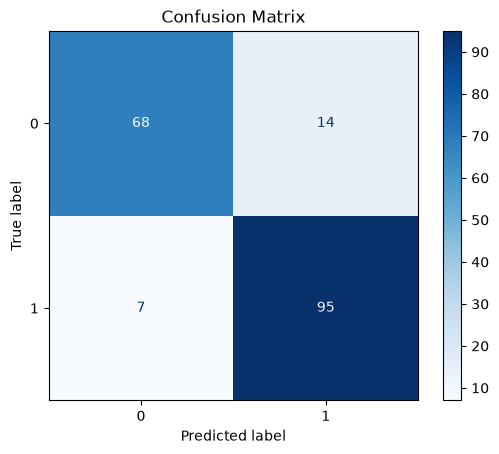

In [71]:
# Plot Confusion Matrix

import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay(confusion_matrix=cm).plot(cmap="Blues")

plt.title("Confusion Matrix")
plt.show()

In [72]:
# Import Classification Report

from sklearn.metrics import classification_report

In [73]:
# Display Classification Report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.91      0.83      0.87        82
           1       0.87      0.93      0.90       102

    accuracy                           0.89       184
   macro avg       0.89      0.88      0.88       184
weighted avg       0.89      0.89      0.89       184



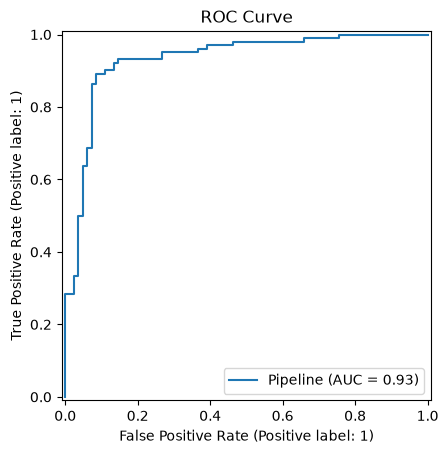

In [75]:
# ROC Curve

from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(
    pipeline,
    X_test,
    y_test
)

plt.title("ROC Curve")
plt.show()

In [76]:
# Cross Validation

from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    pipeline,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

print("CV Scores:", cv_scores)
print("Average CV Accuracy:", cv_scores.mean())

CV Scores: [0.85869565 0.85326087 0.83152174 0.8579235  0.76502732]
Average CV Accuracy: 0.8332858161083394


In [77]:
# Import GridSearchCV

from sklearn.model_selection import GridSearchCV

In [78]:
# Parameters to Test

param_grid = {
    "model__C": [0.1, 1, 10],
    "model__solver": ["liblinear", "lbfgs"]
}

In [79]:
# Create GridSearchCV Object

grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy"
)

In [80]:
# Train GridSearchCV

grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__C': [0.1, 1, ...], 'model__solver': ['liblinear', 'lbfgs']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity

In [81]:
# Display Best Parameters

print("Best Parameters:")
print(grid_search.best_params_)

Best Parameters:
{'model__C': 0.1, 'model__solver': 'lbfgs'}


In [82]:
# Display Best Cross Validation Score

print("Best Cross Validation Accuracy:")
print(grid_search.best_score_)

Best Cross Validation Accuracy:
0.8568819308545337


In [83]:
# Get All Feature Names

feature_names = pipeline.named_steps["preprocessor"].get_feature_names_out()

print(feature_names)

['cat__Sex_F' 'cat__Sex_M' 'cat__ChestPainType_ASY'
 'cat__ChestPainType_ATA' 'cat__ChestPainType_NAP' 'cat__ChestPainType_TA'
 'cat__RestingECG_LVH' 'cat__RestingECG_Normal' 'cat__RestingECG_ST'
 'cat__ExerciseAngina_N' 'cat__ExerciseAngina_Y' 'cat__ST_Slope_Down'
 'cat__ST_Slope_Flat' 'cat__ST_Slope_Up' 'remainder__Age'
 'remainder__RestingBP' 'remainder__Cholesterol' 'remainder__FastingBS'
 'remainder__MaxHR' 'remainder__Oldpeak']


In [84]:
# Get Logistic Regression Coefficients

coefficients = pipeline.named_steps["model"].coef_[0]

In [85]:
# Create Coefficient Table

importance = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

importance.head()

,Feature,Coefficient
0,cat__Sex_F,-0.565308
1,cat__Sex_M,0.639768
2,cat__ChestPainType_ASY,1.229664
3,cat__ChestPainType_ATA,-0.481369
4,cat__ChestPainType_NAP,-0.597569


In [86]:
# Sort Features by Coefficient

importance = importance.sort_values(
    by="Coefficient",
    ascending=False
)

importance

,Feature,Coefficient
2,cat__ChestPainType_ASY,1.229664
12,cat__ST_Slope_Flat,1.214691
17,remainder__FastingBS,0.773469
1,cat__Sex_M,0.639768
10,cat__ExerciseAngina_Y,0.433079
19,remainder__Oldpeak,0.274879
6,cat__RestingECG_LVH,0.234819
11,cat__ST_Slope_Down,0.122304
14,remainder__Age,0.006574
15,remainder__RestingBP,0.003311


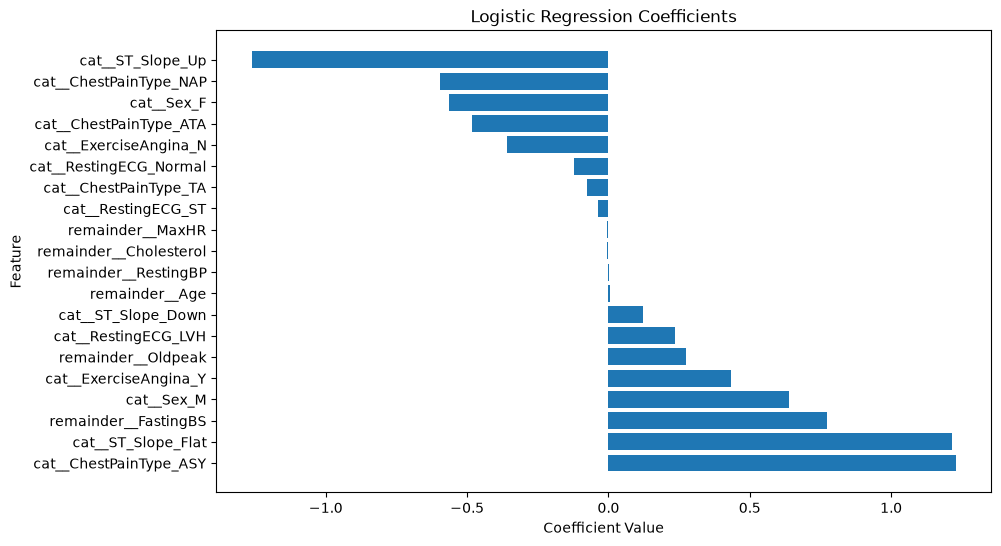

In [87]:
# Plot Coefficients

plt.figure(figsize=(10,6))

plt.barh(
    importance["Feature"],
    importance["Coefficient"]
)

plt.title("Logistic Regression Coefficients")
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")

plt.show()

In [88]:
# Check Target Class Distribution

print(df["HeartDisease"].value_counts())

HeartDisease
1    508
0    410
Name: count, dtype: int64


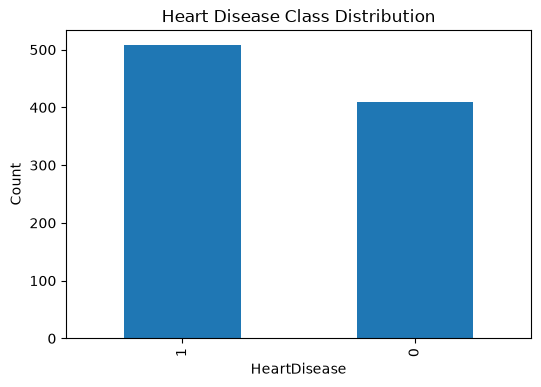

In [89]:
# Plot Target Class Distribution

plt.figure(figsize=(6,4))

df["HeartDisease"].value_counts().plot(
    kind="bar"
)

plt.title("Heart Disease Class Distribution")
plt.xlabel("HeartDisease")
plt.ylabel("Count")

plt.show()